<a href="https://colab.research.google.com/github/oddeeksha/h2-vqe-ibm-quantum-qiskit/blob/main/H2_VQE_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Molecule Energy Estimator using VQE

**Qiskit Fall Fest 2026 – Quantum Build Challenge (Track I5)**

### Objective
Estimate the ground-state energy of the $\text{H}_2$ molecule using the Variational Quantum Eigensolver (VQE), compare its convergence against exact classical solutions, evaluate performance across different optimizers, simulate realistic hardware noise, and execute the algorithm on real IBM Quantum hardware for bonus points.

## Environment Setup

Install the required Qiskit and quantum chemistry packages.

In [ ]:
!pip install qiskit qiskit-aer qiskit-algorithms qiskit-nature pyscf qiskit-ibm-runtime pylatexenc matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.3/113.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.

## Environment Verification
Verify that core quantum and classical chemistry libraries are loaded properly.

In [ ]:
import logging
import qiskit
import qiskit_nature
import pyscf

# Silence noisy IBM Runtime info logs
logging.getLogger('qiskit_ibm_runtime').setLevel(logging.ERROR)

print("Qiskit Version:", qiskit.__version__)
print("PySCF imported successfully")

Qiskit Version: 2.5.2
PySCF imported successfully


## Step 1: Create the $\text{H}_2$ Molecule
Define the electronic structure of molecular hydrogen at its equilibrium bond length ($0.735\text{ Å}$) using PySCF in an STO-3G basis set.

In [ ]:
from qiskit_nature.second_q.drivers import PySCFDriver

bond_distance = 0.735

driver = PySCFDriver(
    atom=f"H 0 0 0; H 0 0 {bond_distance}",
    basis="sto3g"
)

problem = driver.run()
nuclear_repulsion_energy = problem.nuclear_repulsion_energy
print(f"Nuclear Repulsion Energy: {nuclear_repulsion_energy:.6f} Ha")

Nuclear Repulsion Energy: 0.719969 Ha


## Step 2: Generate Molecular Hamiltonian
Extract the second-quantized fermionic Hamiltonian and map it to qubit Pauli operators ($\text{I}, \text{X}, \text{Y}, \text{Z}$) via the Jordan-Wigner transformation.

In [ ]:
from qiskit_nature.second_q.mappers import JordanWignerMapper

mapper = JordanWignerMapper()
second_q_op = problem.hamiltonian.second_q_op()
qubit_hamiltonian = mapper.map(second_q_op)

print("Qubit Hamiltonian:")
print(qubit_hamiltonian)
print(f"Number of Qubits Required: {qubit_hamiltonian.num_qubits}")

Qubit Hamiltonian:
SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.81054798+0.j,  0.17218393+0.j, -0.22575349+0.j,  0.17218393+0.j,
 -0.22575349+0.j,  0.12091263+0.j,  0.16892754+0.j,  0.16614543+0.j,
  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,
  0.16614543+0.j,  0.17464343+0.j,  0.12091263+0.j])
Number of Qubits Required: 4


## Step 3: Exact Classical Benchmark
Compute the exact ground-state energy classically by diagonalizing the qubit Hamiltonian matrix using NumPy. This provides the ground truth benchmark for evaluating VQE accuracy.

In [ ]:
import numpy as np

electronic_exact_energy = np.min(
    np.linalg.eigvalsh(qubit_hamiltonian.to_matrix())
)
exact_total_energy = electronic_exact_energy + nuclear_repulsion_energy

print(f"Exact Electronic Energy:   {electronic_exact_energy:.6f} Ha")
print(f"Exact Total Ground Energy: {exact_total_energy:.6f} Ha")

Exact Electronic Energy:   -1.857275 Ha
Exact Total Ground Energy: -1.137306 Ha


## Step 4a: Variational Quantum Eigensolver (VQE) Concept & Ansatz Setup

VQE is a hybrid quantum-classical algorithm that combines:
1. **A Parameterized Quantum Circuit (Ansatz):** Prepares trial quantum states based on trainable parameters.
2. **A Classical Optimizer:** Evaluates measured energies and continuously updates circuit parameters to find the minimum eigenvalue.

Below, we construct a 4-qubit `TwoLocal` ansatz with $R_y$ single-qubit rotations and linear $CZ$ entanglement blocks.

/tmp/ipykernel_1272/4056993255.py:6: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(


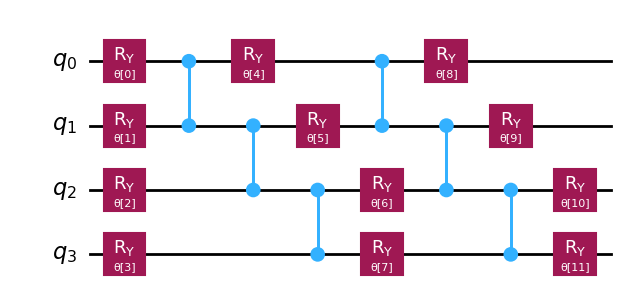

In [ ]:
from qiskit.circuit.library import TwoLocal
from qiskit.primitives import StatevectorEstimator

num_qubits = qubit_hamiltonian.num_qubits

ansatz = TwoLocal(
    num_qubits=num_qubits,
    rotation_blocks="ry",
    entanglement_blocks="cz",
    reps=2,
    entanglement="linear"
)

# Render Circuit
display(ansatz.decompose().draw("mpl"))

estimator = StatevectorEstimator()

## Step 4b: Classical Optimizer Comparison (COBYLA vs. SPSA)

We evaluate VQE convergence using two distinct classical optimizers on an ideal statevector simulator:
* **COBYLA (Constrained Optimization BY Linear Approximations):** A gradient-free local optimizer well-suited for noise-free simulations.
* **SPSA (Simultaneous Perturbation Stochastic Approximation):** A stochastic optimizer tailored to handle noise and shot variance in real quantum hardware.

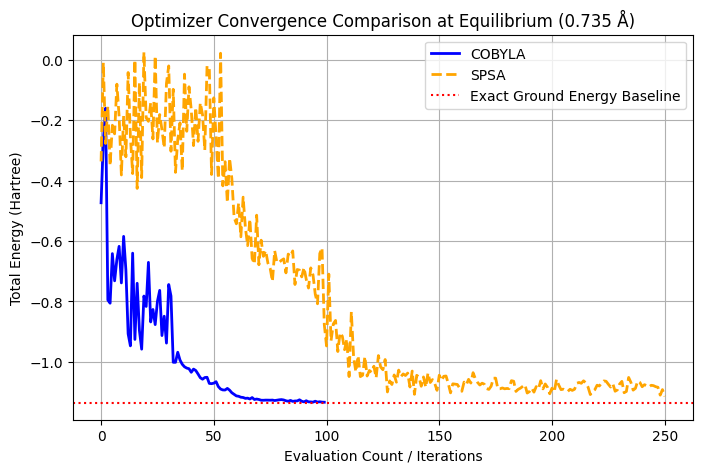

=== OPTIMIZER COMPARISON AT EQUILIBRIUM (0.735 Å) ===
Exact Total Energy:   -1.137306 Ha
COBYLA VQE Energy:    -1.133817 Ha (Error: 0.003489 Ha)
SPSA VQE Energy:      -1.114348 Ha (Error: 0.022958 Ha)


In [ ]:
# Step 4b: Run VQE with COBYLA and SPSA with Convergence Tracking
import matplotlib.pyplot as plt
from qiskit_algorithms.optimizers import COBYLA, SPSA
from qiskit_algorithms import VQE

# Callback lists to track optimization steps
cobyla_history = []
spsa_history = []

def track_cobyla(eval_count, params, value, metadata):
    cobyla_history.append(value + nuclear_repulsion_energy)

def track_spsa(eval_count, params, value, metadata):
    spsa_history.append(value + nuclear_repulsion_energy)

# 1. COBYLA Run
optimizer_cobyla = COBYLA(maxiter=100)
vqe_cobyla = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer_cobyla, callback=track_cobyla)
cobyla_res = vqe_cobyla.compute_minimum_eigenvalue(operator=qubit_hamiltonian)
cobyla_total_energy = cobyla_res.eigenvalue.real + nuclear_repulsion_energy

# 2. SPSA Run
optimizer_spsa = SPSA(maxiter=100)
vqe_spsa = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer_spsa, callback=track_spsa)
spsa_res = vqe_spsa.compute_minimum_eigenvalue(operator=qubit_hamiltonian)
spsa_total_energy = spsa_res.eigenvalue.real + nuclear_repulsion_energy

# 3. Plot Convergence Comparison
plt.figure(figsize=(8, 5))
plt.plot(cobyla_history, label="COBYLA", color="blue", linewidth=2)
plt.plot(spsa_history, label="SPSA", color="orange", linestyle="--", linewidth=2)
plt.axhline(y=exact_total_energy, color="red", linestyle=":", label="Exact Ground Energy Baseline")
plt.xlabel("Evaluation Count / Iterations")
plt.ylabel("Total Energy (Hartree)")
plt.title("Optimizer Convergence Comparison at Equilibrium (0.735 Å)")
plt.legend()
plt.grid(True)
plt.show()

print("=== OPTIMIZER COMPARISON AT EQUILIBRIUM (0.735 Å) ===")
print(f"Exact Total Energy:   {exact_total_energy:.6f} Ha")
print(f"COBYLA VQE Energy:    {cobyla_total_energy:.6f} Ha (Error: {abs(cobyla_total_energy - exact_total_energy):.6f} Ha)")
print(f"SPSA VQE Energy:      {spsa_total_energy:.6f} Ha (Error: {abs(spsa_total_energy - exact_total_energy):.6f} Ha)")

## Step 5: Potential Energy Surface (PES) Scan
Sweep the interatomic bond distance from $0.3\text{ Å}$ to $2.5\text{ Å}$ to build the potential energy surface and locate the equilibrium binding energy.

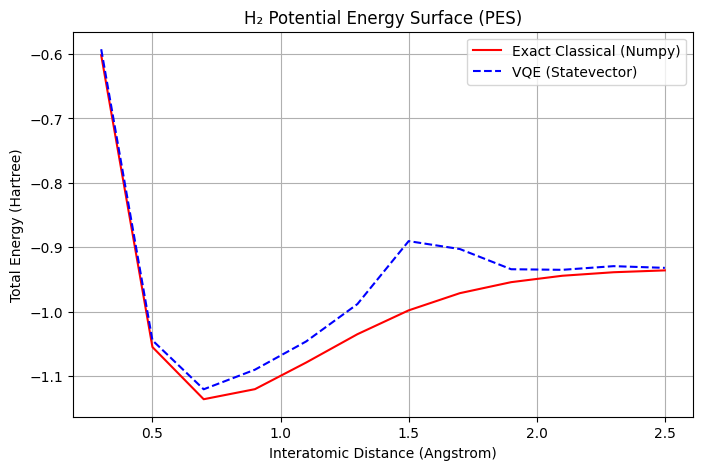

In [ ]:
distances = np.linspace(0.3, 2.5, 12)
exact_energies = []
vqe_energies = []

for dist in distances:
    d = PySCFDriver(atom=f"H 0 0 0; H 0 0 {dist}", basis="sto3g")
    p = d.run()
    q_ham = mapper.map(p.hamiltonian.second_q_op())

    # Exact Calculation
    exact_elec = np.min(np.linalg.eigvalsh(q_ham.to_matrix()))
    exact_energies.append(exact_elec + p.nuclear_repulsion_energy)

    # VQE Calculation
    res = vqe_cobyla.compute_minimum_eigenvalue(operator=q_ham)
    vqe_energies.append(res.eigenvalue.real + p.nuclear_repulsion_energy)

# Plot Results
plt.figure(figsize=(8, 5))
plt.plot(distances, exact_energies, 'r-', label='Exact Classical (Numpy)')
plt.plot(distances, vqe_energies, 'b--', label='VQE (Statevector)')
plt.xlabel('Interatomic Distance (Angstrom)')
plt.ylabel('Total Energy (Hartree)')
plt.title('H₂ Potential Energy Surface (PES)')
plt.legend()
plt.grid(True)
plt.show()

## IBM Quantum Authentication (Google Colab Secrets Setup)
Retrieve IBM Quantum API token securely from Google Colab Secrets without exposing credentials in plain text or committing them to GitHub.

In [ ]:
# Authentication Setup via Colab Secrets
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService

# Retrieve token securely
ibm_token = userdata.get('IBM_QUANTUM_TOKEN')

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=ibm_token,
    overwrite=True
)

print("IBM Quantum API token authenticated successfully!")

IBM Quantum API token authenticated successfully!


## Step 6: Realistic Hardware Noise Simulation
Simulate physical noise (gate errors, readout noise, thermal relaxation) using live device properties pulled from IBM Quantum backends via Qiskit Aer.

In [ ]:
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit.compiler import transpile

service = QiskitRuntimeService()
real_backend = service.backend("ibm_kingston")
print(f"Loaded noise calibration profile from backend: {real_backend.name}")

noisy_simulator = AerSimulator.from_backend(real_backend)
noisy_estimator = AerEstimator.from_backend(noisy_simulator)

transpiled_ansatz = transpile(ansatz, backend=real_backend)

vqe_noisy = VQE(
    estimator=noisy_estimator,
    ansatz=transpiled_ansatz,
    optimizer=optimizer_spsa
)

print("Running VQE under realistic noise...")
noisy_result = vqe_noisy.compute_minimum_eigenvalue(operator=qubit_hamiltonian)
noisy_total_energy = noisy_result.eigenvalue.real + nuclear_repulsion_energy

print(f"\nRealistic Noisy VQE Total Energy: {noisy_total_energy:.6f} Ha")
print(f"Exact Total Energy:               {exact_total_energy:.6f} Ha")
print(f"Energy Error under Real Noise:    {abs(noisy_total_energy - exact_total_energy):.6f} Ha")

Loaded noise calibration profile from backend: ibm_kingston
Running VQE under realistic noise...

Realistic Noisy VQE Total Energy: -1.102307 Ha
Exact Total Energy:               -1.137306 Ha
Energy Error under Real Noise:    0.034999 Ha


## Step 7a: Real IBM Hardware Execution
Execute a single equilibrium point calculation directly on physical IBM Quantum hardware via `qiskit-ibm-runtime`.

In [ ]:
from qiskit import transpile
from qiskit_ibm_runtime.executor_estimator import Estimator

# 0. Pick the optimal parameters from the Step 4b runs (use the lower-energy result)
if cobyla_total_energy <= spsa_total_energy:
    optimal_params = np.asarray(cobyla_res.optimal_point)
    best_optimizer, simulated_energy = "COBYLA", cobyla_total_energy
else:
    optimal_params = np.asarray(spsa_res.optimal_point)
    best_optimizer, simulated_energy = "SPSA", spsa_total_energy

np.save("optimal_params.npy", optimal_params)  # survives a kernel restart
assert len(optimal_params) == ansatz.num_parameters
print(f"Using {best_optimizer} parameters ({len(optimal_params)} values), simulated energy {simulated_energy:.6f} Ha")

hardware_backend = service.backend("ibm_kingston")
print(f"Submitting job to hardware backend: {hardware_backend.name}")

# 1. Bind parameters FIRST, then transpile
bound_ansatz = ansatz.assign_parameters(optimal_params)
hw_transpiled_ansatz = transpile(bound_ansatz, backend=hardware_backend, optimization_level=3)

# 2. Map the observable onto the physical layout
mapped_hamiltonian = qubit_hamiltonian.apply_layout(hw_transpiled_ansatz.layout)

# 3. Submit
runtime_estimator = Estimator(mode=hardware_backend)
job = runtime_estimator.run([(hw_transpiled_ansatz, mapped_hamiltonian)])
print(f"Job successfully queued/submitted! Job ID: {job.job_id()}")

# 4. Results
result = job.result()
hardware_elec_energy = float(result[0].data.evs)
hardware_total_energy = hardware_elec_energy + nuclear_repulsion_energy

print("\n=== REAL HARDWARE RESULT ===")
print(f"Backend Name:           {hardware_backend.name}")
print(f"Simulated Total Energy: {simulated_energy:.6f} Ha")
print(f"Hardware Total Energy:  {hardware_total_energy:.6f} Ha")
print(f"Exact Total Energy:     {exact_total_energy:.6f} Ha")
print(f"Hardware Error:         {abs(hardware_total_energy - exact_total_energy):.6f} Ha")


Using COBYLA parameters (12 values), simulated energy -1.133817 Ha
Submitting job to hardware backend: ibm_kingston
Job successfully queued/submitted! Job ID: db3i3bsvf2bc73ct776g

=== REAL HARDWARE RESULT ===
Backend Name:           ibm_kingston
Simulated Total Energy: -1.133817 Ha
Hardware Total Energy:  -1.099869 Ha
Exact Total Energy:     -1.137306 Ha
Hardware Error:         0.037437 Ha


## Step 7b: Environment Comparison & Accuracy Benchmark

We compare ground-state energy calculations and absolute error deviations across all execution environments relative to exact classical diagonalization:
1. **Ideal Statevector Simulation:** Evaluates parameter performance without physical noise or sampling variance.
2. **Aer Device Noise Model:** Simulates gate errors, readout noise, and thermal relaxation based on live `ibm_kingston` calibration data.
3. **Physical Quantum Hardware:** Single-eval execution directly on `ibm_kingston`.

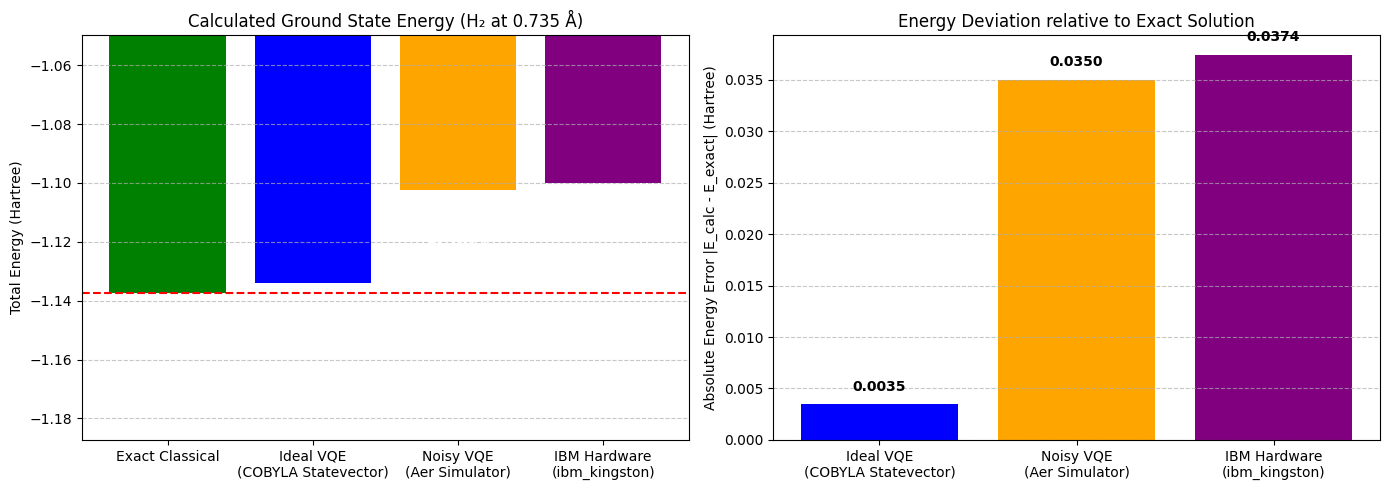

In [ ]:
import matplotlib.pyplot as plt

# Retrieve simulated_energy and best_optimizer from Step 7a
methods = [
    'Exact Classical',
    f'Ideal VQE\n({best_optimizer} Statevector)',
    'Noisy VQE\n(Aer Simulator)',
    'IBM Hardware\n(ibm_kingston)'
]

energies = [
    exact_total_energy,
    simulated_energy,
    noisy_total_energy,
    hardware_total_energy
]

errors = [
    0.0,
    abs(simulated_energy - exact_total_energy),
    abs(noisy_total_energy - exact_total_energy),
    abs(hardware_total_energy - exact_total_energy)
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Calculated Energy Comparison
bars1 = ax1.bar(methods, energies, color=['green', 'blue', 'orange', 'purple'])
ax1.axhline(y=exact_total_energy, color='red', linestyle='--', label='Exact Baseline')
ax1.set_ylabel('Total Energy (Hartree)')
ax1.set_title('Calculated Ground State Energy (H₂ at 0.735 Å)')
ax1.set_ylim([min(energies) - 0.05, max(energies) + 0.05])
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval - 0.02, f"{yval:.4f}", ha='center', va='bottom', color='white', fontweight='bold')

# Plot 2: Absolute Error Comparison
bars2 = ax2.bar(methods[1:], errors[1:], color=['blue', 'orange', 'purple'])
ax2.set_ylabel('Absolute Energy Error |E_calc - E_exact| (Hartree)')
ax2.set_title('Energy Deviation relative to Exact Solution')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of error bars
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.001, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusion & Portfolio Summary

### Results Overview
1. **Ideal VQE Performance:** At the equilibrium distance ($0.735\text{ Å}$) the ideal statevector VQE reached an error of $0.0035\text{ Ha}$ with `COBYLA` and $0.0230\text{ Ha}$ with `SPSA` relative to exact diagonalization. The `COBYLA` result is about 2 times the chemical accuracy threshold ($0.0016\text{ Ha}$); the `SPSA` result is about 14 times that threshold.
2. **Optimizer Benchmarking:** `COBYLA` and `SPSA` were each run once on the ideal simulator with random starting points. In this run `COBYLA` converged smoothly to a lower final energy within roughly 70 evaluations, while `SPSA` was very noisy for its first ~100 evaluations and finished higher (it also logs more evaluations per iteration, so the two x-axes are not directly comparable). Because each optimizer was run once from random starts, this ranking is not conclusive: in an earlier run of this same notebook the ranking was reversed. `SPSA` is designed for noisy, shot-based settings, which the ideal simulation does not test.
3. **PES Mapping:** The exact potential energy surface was computed at 12 interatomic distances ($0.3\text{ Å}$ to $2.5\text{ Å}$). The VQE curve follows it closely at short and long distances but deviates by roughly $0.1\text{ Ha}$ (read from the plot) around $1.5\text{ Å}$. Likely causes are the short `COBYLA` budget (100 iterations), random restarts at every point, and a zero-state starting circuit that can get trapped in local minima.
4. **Hardware Validation:** The best ideal-simulation parameters (`COBYLA`) were evaluated on `ibm_kingston` (Job ID: `db3i3bsvf2bc73ct776g`), giving $-1.0999\text{ Ha}$ (error $0.0374\text{ Ha}$) with no error mitigation.

### Execution Environment Benchmarks
```text
Environment                            Total Energy (Ha)    Error vs. Exact (Ha)
Exact Classical Baseline                       -1.137306                0.000000
Ideal VQE (COBYLA Statevector)                 -1.133817                0.003489
Noisy VQE (Aer Simulator)                      -1.102307                0.034999
Physical IBM Hardware (ibm_kingston)           -1.099869                0.037437
```

### Analytical Insights & Error Analysis
* **Hardware Noise Impact:** Ideal Statevector ($0.0035\text{ Ha error}$) $\rightarrow$ Aer Noise Simulation ($0.0350\text{ Ha error}$) $\rightarrow$ Physical Hardware ($0.0374\text{ Ha error}$). Simulated noise added about $0.0315\text{ Ha}$ and physical hardware added about $0.0339\text{ Ha}$ above the ideal simulation. The Aer noise model and the real device agree to within about $0.0024\text{ Ha}$ in this single run, which suggests the calibration-based noise model captures much of the hardware error, though one run is not enough to confirm this.
* **Comparison Caveat:** The Aer run re-optimizes the parameters with `SPSA` under noise from a fresh random start, while the hardware run is a single evaluation of the ideal-simulation `COBYLA` parameters with no error mitigation. The two are therefore not identical experiments.
* **Hardware Run-to-Run Variation:** In earlier sessions, two runs of the same circuit on the same backend (Job IDs: `db3hft4lf4us73c1ab90` and `db3hlu4lf4us73c1an20`) gave $-1.0820\text{ Ha}$ and $-1.0769\text{ Ha}$, a spread of about $0.005\text{ Ha}$. A single hardware evaluation therefore carries run-to-run variation of that order.
* **Chemical Accuracy ($0.0016\text{ Ha}$):** The heuristic `TwoLocal` ansatz starts from the default zero state $\vert{}0000\rangle$ without a Hartree-Fock reference state (which, under the Jordan-Wigner mapping used here, is $\vert{}0101\rangle$). Prepending a `HartreeFock` initial state and allowing more optimizer iterations would be expected to reduce the ideal ansatz error toward chemical accuracy.

**Takeaway:** VQE on $\text{H}_2$ works well in ideal simulation (error $0.0035\text{ Ha}$), and device noise raises the error roughly tenfold on real hardware ($0.0374\text{ Ha}$). Accuracy beyond that would need a better starting state, more optimizer iterations, and error mitigation.